# 01 EDA — Stepik course-step dataset

Проверяем размер датасета, пропуски, распределение таргета и базовые зависимости.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

DATA = Path('../data/processed/stepik_course_steps_processed.csv')
df = pd.read_csv(DATA)
df.shape

(16289, 53)

In [2]:
df.head()

,course_id,section_id,unit_id,lesson_id,step_id,title,summary,description,language,lesson_title,...,lesson_title_len,title_word_count,description_word_count,lesson_title_word_count,created_year,created_month,_source,_parsed_page,_parsed_at_utc,split
0,284860,695647,2382760,2347378,10080081,Классификация углеводородов,Курс посвящён изучению классификации углеводор...,<p>Этот курс — первый шаг в изучении органичес...,ru,Алканы: строение и первые представители,...,39,2,56,5,2026,4,stepik,3,2026-04-25T18:50:41Z,train
1,284860,695647,2382760,2347378,10080082,Классификация углеводородов,Курс посвящён изучению классификации углеводор...,<p>Этот курс — первый шаг в изучении органичес...,ru,Алканы: строение и первые представители,...,39,2,56,5,2026,4,stepik,3,2026-04-25T18:50:41Z,train
2,284860,695647,2382760,2347378,10080098,Классификация углеводородов,Курс посвящён изучению классификации углеводор...,<p>Этот курс — первый шаг в изучении органичес...,ru,Алканы: строение и первые представители,...,39,2,56,5,2026,4,stepik,3,2026-04-25T18:50:41Z,train
3,284860,695647,2382760,2347378,10080118,Классификация углеводородов,Курс посвящён изучению классификации углеводор...,<p>Этот курс — первый шаг в изучении органичес...,ru,Алканы: строение и первые представители,...,39,2,56,5,2026,4,stepik,3,2026-04-25T18:50:41Z,train
4,284860,695647,2382760,2347378,10080138,Классификация углеводородов,Курс посвящён изучению классификации углеводор...,<p>Этот курс — первый шаг в изучении органичес...,ru,Алканы: строение и первые представители,...,39,2,56,5,2026,4,stepik,3,2026-04-25T18:50:41Z,train


In [3]:
pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_share': df.isna().mean(),
    'nunique': df.nunique(dropna=True),
}).sort_values('missing_share', ascending=False).head(25)

,dtype,missing_share,nunique
step_cost,float64,1.000000,0
videos_duration,float64,1.000000,0
sections_count,float64,1.000000,0
rating,float64,1.000000,0
reviews_count,float64,1.000000,0
unit_progress_weight,float64,1.000000,0
submissions_count,float64,1.000000,0
price_numeric,float64,0.492971,140
time_to_complete,float64,0.360243,341
description,object,0.130824,500


In [4]:
df[['learners_count', 'target_log_learners_count']].describe()

,learners_count,target_log_learners_count
count,16289.000000,16289.000000
mean,49.255633,2.208334
std,133.011988,1.803425
min,0.000000,0.000000
25%,1.000000,0.693147
50%,8.000000,2.197225
75%,32.000000,3.496508
max,1054.000000,6.961296


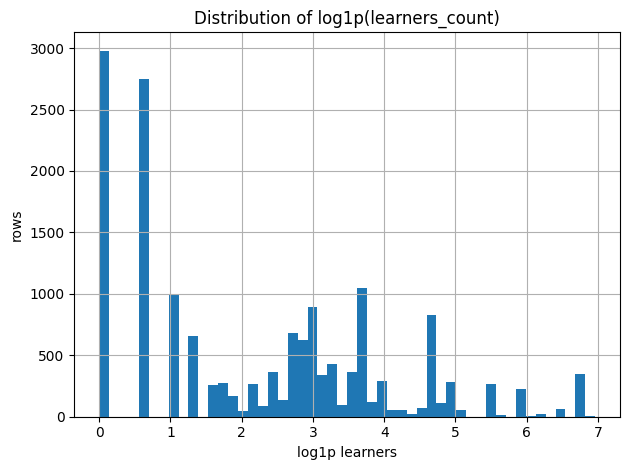

In [5]:
ax = df['target_log_learners_count'].hist(bins=50)
ax.set_title('Distribution of log1p(learners_count)')
ax.set_xlabel('log1p learners')
ax.set_ylabel('rows')
plt.tight_layout()

In [6]:
df['split'].value_counts(normalize=True).rename('share')

split
train    0.794524
val      0.104242
test     0.101234
Name: share, dtype: float64

In [7]:
course_split_counts = df.groupby('course_id')['split'].nunique()
assert course_split_counts.max() == 1, 'leakage: a course appears in multiple splits'
course_split_counts.describe()

count    600.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: split, dtype: float64

In [8]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr(numeric_only=True)['target_log_learners_count'].sort_values(key=lambda s: s.abs(), ascending=False)
corr.head(20)

target_log_learners_count    1.000000
learners_count               0.660877
_parsed_page                 0.297645
lesson_steps_count           0.290100
course_id                   -0.289470
lessons_count                0.277412
unit_id                     -0.254121
section_id                  -0.250907
created_month               -0.207923
description_len              0.207043
description_word_count       0.194595
step_position_in_lesson      0.191287
price_numeric                0.185755
section_position             0.184187
time_to_complete             0.176835
lesson_id                   -0.171879
step_id                     -0.160514
title_len                   -0.143792
summary_len                 -0.142438
title_word_count            -0.136206
Name: target_log_learners_count, dtype: float64